## Inspect Partition
Evaluate Wang and Jordan partitions

In [ ]:
%matplotlib ipympl
import matplotlib.pyplot as plt
import numpy as np

from buildforcing.metfuncs import (
    calculate_wetbulb, rh_to_q,
    wang2019_snowfrac, jordan_snowfrac
)

#### Verify wetbulb curve

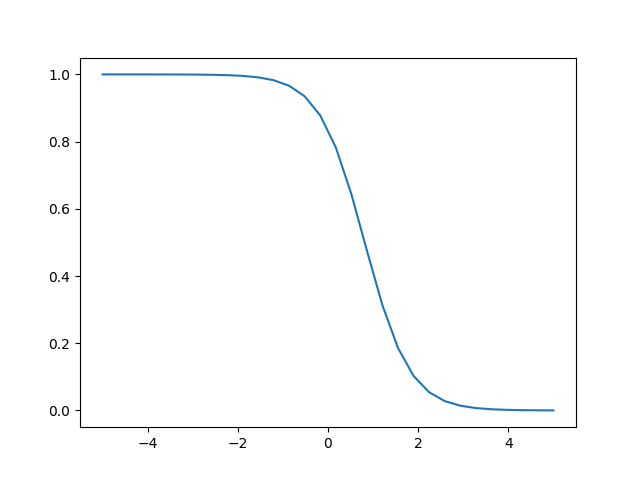

In [7]:
# Setup parameters
Twb_range = np.linspace(-5, 5, 30)  # Temperature in C
snow_fracs = wang2019_snowfrac(Twb_range)

plt.figure()
plt.plot(Twb_range,snow_fracs)
plt.show()

### Verify with humidity

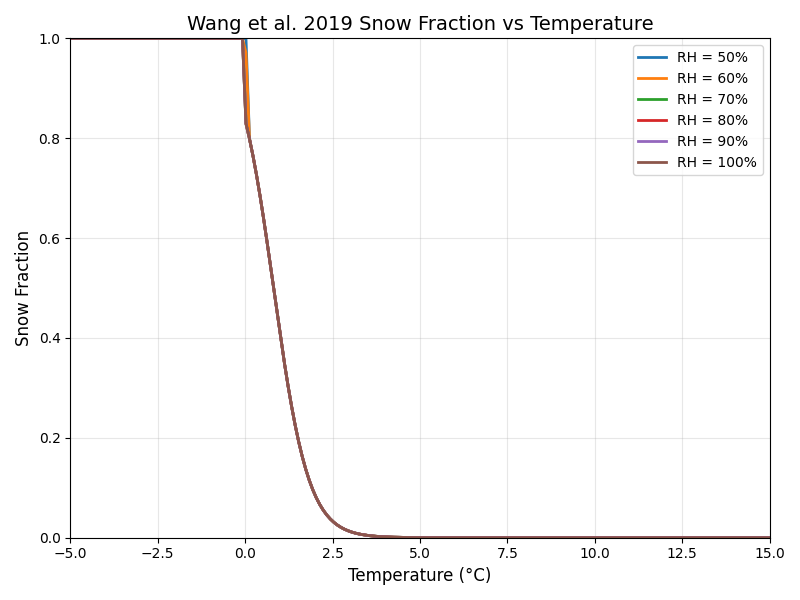

In [ ]:


# Setup parameters
temp_range = np.linspace(-5, 15, 200)  # Temperature in C
rh_values = np.arange(50, 101, 10)  # Relative humidity from 50% to 100%
pressure_value = 100000  # Pa (constant)

# Create figure
fig, ax = plt.subplots(figsize=(8, 6))

# Plot snow fraction for each RH value
for rh in rh_values:
    # Create arrays with same length as temp_range
    temp_array = temp_range
    rh_array = np.full_like(temp_array, rh)
    pressure_array = np.full_like(temp_array, pressure_value)
    
    # Calculate wet bulb temperature
    q = rh_to_q(temp_array, rh_array, pressure_array)
    twet = calculate_wetbulb(temp_array, q, pressure_array)
    
    # Calculate snow fraction using wet bulb temperature
    snow_fracs = wang2019_snowfrac(twet)
    
    ax.plot(temp_array, snow_fracs, label=f'RH = {rh}%', linewidth=2)

# Format plot
ax.set_xlabel('Temperature (°C)', fontsize=12)
ax.set_ylabel('Snow Fraction', fontsize=12)
ax.set_title('Wang et al. 2019 Snow Fraction vs Temperature', fontsize=14)
ax.legend(loc='best')
ax.grid(True, alpha=0.3)
ax.set_xlim(-5, 15)
ax.set_ylim(0, 1)

plt.tight_layout()
plt.show()